# FEM Pendulum Mesh and Contact Figure Export

This notebook creates thesis-ready visualizations of the FEM pendulum model used in the controlled-pendulum case study.
It exports a reference mesh with named boundary regions and a representative deformed contact configuration.
The WebGUI and ParaView export cells at the end are optional inspection tools.


## Imports and Paths


In [12]:
from pathlib import Path
import logging
import sys
from collections import Counter, defaultdict

import numpy as np
import matplotlib as mpl
if "ipykernel" not in sys.modules:
    mpl.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import ListedColormap

from ngsolve import BND, CF, VOL, VTKOutput
from ngsolve.webgui import Draw


In [13]:
_repo = Path.cwd().resolve()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent

if str(_repo) not in sys.path:
    sys.path.insert(0, str(_repo))

FIG_DIR = _repo / "thesis" / "figures" / "6_case_study" / "controlled_pendulum"
FIG_DIR.mkdir(parents=True, exist_ok=True)

from demos.ControlledPendulum.src.master_pendulum.components.fem.fem_pendulum import FEMPendulum
from demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config import (
    AnimationParameters,
    ContactParameters,
    GeometryParameters,
    InitialConditionParameters,
    MaterialParameters,
    MeshParameters,
    SimulationParameters,
)
from syssimx import EventConnection, System

from notebooks.plot_setup import set_professional_style, FULL_WIDTH, HALF_WIDTH
set_professional_style(latex=True)

<module 'matplotlib.pyplot' from 'c:\\Users\\flori\\anaconda3\\envs\\env-312\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [14]:
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
})


## FEM Model Setup

The model uses the same mesh and boundary names as the case-study FEM pendulum.
The time step can be increased during layout work, but the exported thesis figure should use the final case-study settings.


In [15]:
FEM_DT = 0.01
T_END = 0.30
INITIAL_THETA_RAD = 0.30

### Contact Parameters

In [16]:
def build_stiff_parameters():
    mat_prams = MaterialParameters()
    contact_params = ContactParameters()
    return mat_prams, contact_params

def build_compliant_parameters():
    mat_params = MaterialParameters(model="neo_hookean",
                                    E_pendulum=1e5, nu_pendulum=0.45, rho_pendulum=1000)
    contact_params = ContactParameters(kn=3e7)
    return mat_params, contact_params


In [17]:
mode = "stiff"  # "stiff" or "compliant"
if mode == "stiff":
    mat_params, contact_params = build_stiff_parameters()
elif mode == "compliant":
    mat_params, contact_params = build_compliant_parameters()
else:
    raise ValueError(f"unknown mode {mode}")

geom_params = GeometryParameters()
mesh_params = MeshParameters()

init_params = InitialConditionParameters(
    angular_position_deg=np.rad2deg(INITIAL_THETA_RAD),
    angular_velocity=0.0,
    drive_torque=0.0,
)

sim_params = SimulationParameters(
    tau=FEM_DT,
    t_end=T_END,
    use_gravity=True,
    with_contact=True,
)

anim_params = AnimationParameters(animate=False)

model = FEMPendulum(name="FEM_Pendulum", group="Plant")
model.set_parameters(
    geom_params=geom_params,
    mat_params=mat_params,
    mesh_params=mesh_params,
    init_params=init_params,
    contact_params=contact_params,
    sim_params=sim_params,
    anim_params=anim_params,
)
model.initialize(0.0)


def wall_contact_event_indicator(comp: FEMPendulum) -> float:
    theta = comp.get_outputs()["theta"]
    if hasattr(theta, "magnitude"):
        theta = theta.magnitude
    return float(theta)


model.add_event_indicator(
    name="wall_hit",
    func=wall_contact_event_indicator,
    direction=-1,
)

system = System(name="FEM_Pendulum_System")
system.add_component(model)
system.add_event_connection(
    EventConnection(
        src_comp=model.name,
        src_port=model.output_specs["wall_hit"].name,
        dst_comp=model.name,
        dst_port=model.input_specs["omega_invert"].name,
    )
)
system.initialize(0.0)


## Mesh Extraction Helpers

The reference mesh contains volume elements for the pendulum and the wall.
Boundary elements carry the named regions used by the FEM model.


In [18]:
def extract_ngsolve_mesh(mesh):
    """Return vertex coordinates, triangle connectivity, material names, and boundary segments."""
    points = []
    point_index = {}
    triangles = []
    materials = []

    for element in mesh.Elements(VOL):
        vertex_ids = []
        for vertex in element.vertices:
            key = tuple(np.round(mesh[vertex].point[:2], 14))
            if key not in point_index:
                point_index[key] = len(points)
                points.append(key)
            vertex_ids.append(point_index[key])

        if len(vertex_ids) == 3:
            triangles.append(vertex_ids)
            materials.append(element.mat)

    boundary_segments = defaultdict(list)
    for element in mesh.Elements(BND):
        vertex_ids = []
        for vertex in element.vertices:
            key = tuple(np.round(mesh[vertex].point[:2], 14))
            if key not in point_index:
                point_index[key] = len(points)
                points.append(key)
            vertex_ids.append(point_index[key])

        if len(vertex_ids) == 2:
            boundary_segments[element.mat].append(tuple(vertex_ids))

    return (
        np.asarray(points, dtype=float),
        np.asarray(triangles, dtype=int),
        materials,
        dict(boundary_segments),
    )


def boundary_center(coords, segments):
    points = np.asarray([coords[idx] for seg in segments for idx in seg], dtype=float)
    return points.mean(axis=0)


def vector_field_at_vertices(gf, coords):
    values = []
    for x, y in coords:
        value = gf(model._mesh(float(x), float(y)))
        values.append([float(value[0]), float(value[1])])
    return np.asarray(values)


def scalar_field_at_vertices(gf, coords):
    values = []
    for x, y in coords:
        values.append(float(gf(model._mesh(float(x), float(y)))))
    return np.asarray(values)


In [19]:
coords, triangles, materials, boundaries = extract_ngsolve_mesh(model._mesh)
triangulation = mtri.Triangulation(coords[:, 0], coords[:, 1], triangles)

print("Volume materials:", Counter(materials))
print("Boundary names:", Counter({name: len(segments) for name, segments in boundaries.items()}))


Volume materials: Counter({'pendulum': 1307, 'wall': 333})
Boundary names: Counter({'contact_head': 118, 'default': 117, 'contact_wall': 83, 'fix': 26, 'rotation': 20})


## Matplotlib Plotting Helpers

The debug view keeps a 0.5 cm grid visible for label placement.
The final export hides the grid and keeps only the mesh, colored boundaries, and labels.


In [20]:
BOUNDARY_STYLES = {
    "rotation": {
        "color": "#0072B2",
        "label": "pivot / torque",
        "linewidth": 2.8,
        "offset": (8, 12),
    },
    "contact_head": {
        "color": "#D55E00",
        "label": "pendulum contact",
        "linewidth": 2.4,
        "offset": (34, -6),
    },
    "contact_wall": {
        "color": "#CC79A7",
        "label": "wall contact",
        "linewidth": 2.4,
        "offset": (-72, 0),
    },
    "fix": {
        "color": "0.20",
        "label": "fixed wall",
        "linewidth": 2.4,
        "offset": (-58, -14),
    },
}

MESH_STYLE = {
    "color": "0.42",
    "linewidth": 0.30,
    "alpha": 0.85,
}

MATERIAL_COLORS = {
    "pendulum": "#DCEBF3",  # light blue-gray
    "wall": "#EFE3D1",      # light sand
}

def setup_mesh_axes(ax, points, show_grid=False, grid_step=0.005, pad=0.014):
    ax.set_aspect("equal")
    ax.set_xlim(points[:, 0].min() - pad, points[:, 0].max() + pad)
    ax.set_ylim(points[:, 1].min() - pad, points[:, 1].max() + pad)
    ax.set_axisbelow(True)

    if show_grid:
        ax.xaxis.set_major_locator(MultipleLocator(grid_step))
        ax.yaxis.set_major_locator(MultipleLocator(grid_step))
        ax.grid(True, which="major", color="0.86", linewidth=0.35, zorder=0)
    else:
        ax.grid(False)

    ax.tick_params(
        left=False,
        bottom=False,
        labelleft=False,
        labelbottom=False,
    )
    for spine in ax.spines.values():
        spine.set_visible(False)


def draw_named_boundaries(ax, base_coords, boundary_segments, line_coords=None, annotate=False):
    if line_coords is None:
        line_coords = base_coords

    handles = []
    for name, style in BOUNDARY_STYLES.items():
        segments = boundary_segments.get(name, [])
        if not segments:
            continue

        line_handle = None
        for segment in segments:
            xy = line_coords[list(segment)]
            (line_handle,) = ax.plot(
                xy[:, 0],
                xy[:, 1],
                color=style["color"],
                linewidth=style["linewidth"],
                solid_capstyle="round",
                zorder=5,
            )

        handles.append(line_handle)

        if annotate:
            center = boundary_center(line_coords, segments)
            ax.annotate(
                style["label"],
                xy=center,
                xytext=style["offset"],
                textcoords="offset points",
                fontsize=8,
                color=style["color"],
                ha="left",
                va="center",
                arrowprops={
                    "arrowstyle": "-",
                    "color": style["color"],
                    "linewidth": 0.8,
                    "shrinkA": 0,
                    "shrinkB": 2,
                },
                zorder=6,
            )

    return handles


def add_boundary_legend(ax, handles):
    labels = [BOUNDARY_STYLES[name]["label"]
              for name in BOUNDARY_STYLES if boundaries.get(name)]
    legend = ax.legend(
        handles, labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=2,
        frameon=True, framealpha=0.95,
        facecolor="white", edgecolor="0.70",
        handlelength=2.2, borderpad=0.45,
        columnspacing=1.2, labelspacing=0.35,
    )
    legend.set_zorder(10)
    return legend


def save_figure(fig, stem):
    pdf = FIG_DIR / f"{stem}.pdf"
    png = FIG_DIR / f"{stem}.png"
    fig.savefig(pdf, bbox_inches="tight")
    fig.savefig(png, dpi=300, bbox_inches="tight")
    print(f"wrote {pdf.relative_to(_repo)}")
    print(f"wrote {png.relative_to(_repo)}")


In [21]:
def plot_reference_mesh(show_grid=False, annotate=False, legend=True):
    fig, ax = plt.subplots(figsize=(HALF_WIDTH, 1.55*HALF_WIDTH))
    setup_mesh_axes(ax, coords, show_grid=show_grid)

    ax.triplot(
        triangulation,
        zorder=1,
        **MESH_STYLE,
    )

    for material, color in MATERIAL_COLORS.items():
        mask = np.array([mat == material for mat in materials])
        ax.tripcolor(
            coords[:, 0],
            coords[:, 1],
            triangles[mask],
            facecolors=np.ones(mask.sum()),
            cmap=ListedColormap([color]),
            edgecolors="none",
            alpha=0.65,
            zorder=0,
        )

    x_p, y_p = 0, -model.geom_params.l_center/6
    x_w, y_w = -model.geom_params.r_head - model.geom_params.wall_len_x/2, -model.geom_params.l_center
    ax.text(x_p, y_p,
            "pendulum", color="0", fontsize=9,
            backgroundcolor="white", bbox=dict(boxstyle="round,pad=0.1", facecolor="white", edgecolor="none", alpha=1),
            va="center", ha="center")
    
    ax.text(x_w, y_w,
            "wall", color="0", fontsize=9, rotation=90,
            backgroundcolor="white", bbox=dict(boxstyle="round,pad=0.1", facecolor="white", edgecolor="none", alpha=1),
            va="center", ha="center")
        
    handles = draw_named_boundaries(
        ax,
        coords,
        boundaries,
        annotate=annotate,
    )
    if legend:
        add_boundary_legend(ax, handles)
    fig.tight_layout()
    return fig, ax


wrote thesis\figures\6_case_study\controlled_pendulum\fem_mesh_boundaries.pdf
wrote thesis\figures\6_case_study\controlled_pendulum\fem_mesh_boundaries.png


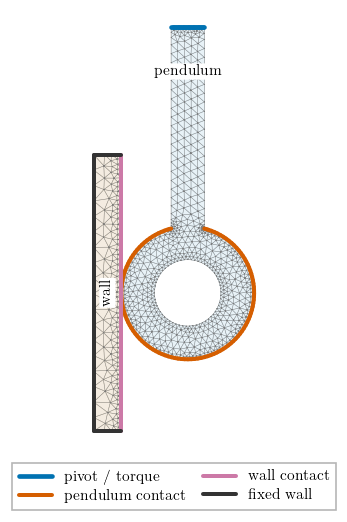

In [22]:
fig, ax = plot_reference_mesh(show_grid=False, annotate=False, legend=True)
save_figure(fig, "fem_mesh_boundaries")
plt.show()

## Contact Simulation for Deformed-State Export

The following cells run the FEM pendulum until the first wall contact has occurred.
The exported deformation figure uses the final state by default.
If a different instant is needed, rerun the simulation with a shorter `T_END` or restore a saved state before plotting.


In [218]:
system.algorithm.debug = False
system.algorithm.locate_events = True
system.algorithm.event_tol = 1e-9
system.algorithm.max_event_iters = 50
system.algorithm.tol = 1e-9
system.algorithm.eps_time = 1e-12
system.algorithm.continuous_algorithm = "GaussSeidel"

system.run(t0=0.0, tf=T_END, dt=FEM_DT)


INFO: Starting simulation run from t=0.0 to t=0.3 with dt=0.01
INFO: ================================================================================
INFO: Event crossing in [0.230000, 0.240000]: FEM_Pendulum.wall_hit
INFO: Event located at t=0.23908281
INFO: Handling 1 event(s) at t=0.23908281, micro=0: FEM_Pendulum.wall_hit
INFO: ================================================================================


[FEM_Pendulum] Event 'wall_hit' at t=0.239083s.


INFO: Simulation completed in 144.73 seconds


In [219]:
history = system.get_history()
time_values, pendulum_data = history[model.name]
event_times = history["Events"].get((model.name, "wall_hit"), [])

print(f"Recorded {len(time_values)} output samples")
print(f"Detected {len(event_times)} wall-hit events")
if event_times:
    print("First wall hit:", event_times[0])


Recorded 454 output samples
Detected 1 wall-hit events
First wall hit: (0.23908281, 0)


## Animate Deformation

In [220]:
model.animate_stress()

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 15}}, …

## Deformed Contact State

The deformation plot uses the current FEM state at the peak-stress
frame. Stress is now computed on both the pendulum and the wall
because `FEMPendulum` extends the post-processed Cauchy and von Mises
fields to the full mesh.  The full-body figure shows the pendulum
deformation with the wall as the contact partner.  The zoom panel
focuses on the contact band where both bodies carry the highest
stress.


In [221]:
# After system.run(...):
print(f"history frames: {len(model._gf_u_history.vecs)}")
# expect this to be ≪ 409 — closer to the number of accepted internal steps

peak_frame = max(
    range(len(model._gf_von_mises_history.vecs)),
    key=lambda i: float(np.abs(model._gf_von_mises_history.vecs[i].FV().NumPy()).max()),
)
print(f"peak von-Mises frame: {peak_frame}")


history frames: 128
peak von-Mises frame: 70


In [222]:
from contextlib import contextmanager

@contextmanager
def history_frame(model, index):
    """Temporarily load FEM history frame `index` into the working gridfunctions.

    `_gf_u_history` stores displacement only (V), while `_gf_u` is on the
    mixed space (V * Q**2). Swap on `_gf_u.components[0]` to match the
    history vector size.
    """
    pairs = [
        (model._gf_u.components[0], model._gf_u_history),   # <-- .components[0]
        (model._gf_von_mises,       model._gf_von_mises_history),
    ]
    n_frames = len(pairs[0][1].vecs)
    if index < 0 or index >= n_frames:
        raise IndexError(
            f"frame {index} out of range for history with {n_frames} stored frames"
        )

    backups = []
    try:
        for working, history in pairs:
            backup = working.vec.CreateVector()
            backup.data = working.vec
            backups.append((working, backup))
            working.vec.data = history.vecs[index]
        yield
    finally:
        for working, backup in backups:
            working.vec.data = backup



In [223]:
def mark_max_value(
    ax,
    coords_plot,
    values,
    label=None,
    marker_size=14,
    label_position=(0.5, 0.045),
):
    """Mark the vertex with the largest scalar value and place a fixed label."""
    idx = int(np.nanargmax(values))
    point = coords_plot[idx]
    max_value = float(values[idx])

    ax.scatter(
        point[0],
        point[1],
        s=marker_size,
        marker="o",
        facecolor="white",
        edgecolor="black",
        linewidth=0.65,
        zorder=8,
    )

    if label is not None:
        if callable(label):
            label_text = label(max_value)
        else:
            label_text = str(label).replace("{value}", f"{max_value:.3g}")

        ax.annotate(
            label_text,
            xy=point,
            xycoords="data",
            xytext=label_position,
            textcoords="axes fraction",
            fontsize=8,
            color="0.1",
            ha="center",
            va="bottom",
            arrowprops=dict(
                arrowstyle="-",
                color="0.1",
                linewidth=0.75,
                shrinkA=2,
                shrinkB=2,
            ),
            bbox=dict(
                facecolor="white",
                edgecolor="0.75",
                alpha=0.92,
                pad=1.5,
            ),
            zorder=9,
        )

    return idx, point, max_value


In [246]:
def plot_deformed_state(
    displacement_scale=1.0,
    field="displacement",
    show_grid=False,
    show_boundaries=True,
    frame=None,
    vmax=None,
    zoom_to_contact=False,
    cmap="viridis",
    n_levels=8,
    mark_max=False,
    max_label=True,
):
    if frame is None:
        frame = len(model._gf_u_history.vecs) - 1

    with history_frame(model, frame):
        u = vector_field_at_vertices(model._gf_u.components[0], coords)
        deformed_coords = coords + displacement_scale * u
        deformed_triangulation = mtri.Triangulation(
            deformed_coords[:, 0],
            deformed_coords[:, 1],
            triangles,
        )

        if field == "von_mises":
            values = scalar_field_at_vertices(model._gf_von_mises, coords) / 1e6
            colorbar_label = r"$\sigma_\mathrm{vM}$ in $\mathrm{MPa}$"
            marker_label = lambda value: rf"$\sigma_\mathrm{{vM,\,max}}$ = {value:.2f} MPa"
        elif field == "displacement":
            values = np.linalg.norm(u, axis=1)
            colorbar_label = r"$\|\mathbf{u}\|$ in m"
            marker_label = lambda value: rf"max $\|\mathbf{{u}}\|$ = {value:.2e} m"
        else:
            raise ValueError("field must be 'displacement' or 'von_mises'")

        vmin = 0.0
        vmax_plot = vmax if vmax is not None else float(np.nanmax(values))

        fig, ax = plt.subplots(figsize=(HALF_WIDTH, 1.55 * HALF_WIDTH))
        setup_mesh_axes(ax, deformed_coords, show_grid=show_grid)

        # Build evenly spaced level boundaries between 0 and vmax (or the data max).
        top = vmax if vmax is not None else float(np.nanmax(values))
        levels = np.linspace(0.0, top, n_levels + 1)

        pc = ax.tricontourf(
            deformed_triangulation, values,
            levels=levels,
            cmap=cmap,                   # plain string or Colormap; tricontourf handles discretization
            #extend="max",                # adds the ▲ on the colorbar when vmax clips
            zorder=1,
        )

        #discrete_cmap = plt.get_cmap(cmap, n_levels)
        # pc = ax.tripcolor(
        #     deformed_triangulation,
        #     values,
        #     shading="gouraud",
        #     cmap=levels,
        #     zorder=1,
        #     vmin=vmin,
        #     vmax=vmax_plot,
        # )
        ax.triplot(
            deformed_triangulation,
            color="0.15",
            linewidth=0.18,
            alpha=0.45,
            zorder=2,
        )

        if show_boundaries:
            draw_named_boundaries(
                ax,
                coords,
                boundaries,
                line_coords=deformed_coords,
                annotate=False,
            )

        if mark_max:
            label = marker_label if max_label else None
            mark_max_value(
                ax,
                deformed_coords,
                values,
                label=label,
            )

        if zoom_to_contact:
            r_head = model.geom_params.r_head
            cx = -r_head
            cy = -model.geom_params.l_center
            ax.set_xlim(cx - model.geom_params.wall_len_x * 1.1, cx + 0.6 * r_head)
            ax.set_ylim(cy - r_head, cy + r_head)

        cbar = fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(colorbar_label)
        cbar.set_ticks([0.0, 0.1, 0.2, 0.3, 0.4])
        if vmax is not None and np.nanmax(values) > vmax:
            cbar.ax.text(
                2.2,
                1.01,
                "clipped",
                transform=cbar.ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=7,
                color="0.35",
            )
        fig.tight_layout()
        return fig, ax


peak von-Mises frame 70, peak 0.441 MPa (now covering pendulum and wall)
wrote thesis\figures\6_case_study\controlled_pendulum\fem_deformed_contact_von_mises.pdf
wrote thesis\figures\6_case_study\controlled_pendulum\fem_deformed_contact_von_mises.png


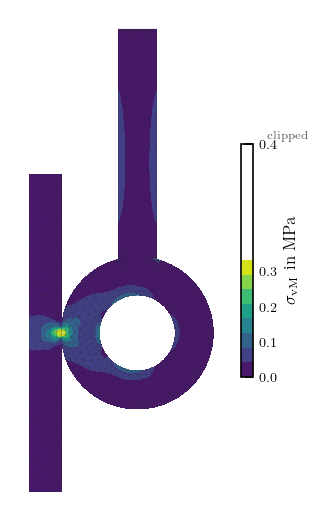

wrote thesis\figures\6_case_study\controlled_pendulum\fem_deformed_contact_von_mises_zoom.pdf
wrote thesis\figures\6_case_study\controlled_pendulum\fem_deformed_contact_von_mises_zoom.png


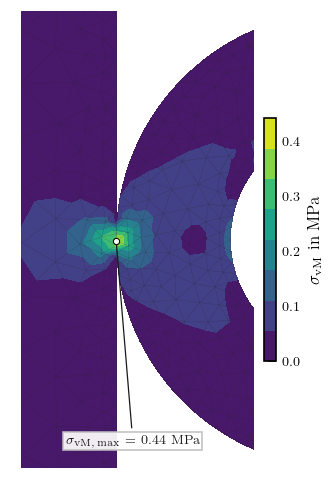

In [247]:
peak_frame = max(
    range(len(model._gf_von_mises_history.vecs)),
    key=lambda i: float(np.abs(model._gf_von_mises_history.vecs[i].FV().NumPy()).max()),
)
vm_peak_pa  = float(np.abs(model._gf_von_mises_history.vecs[peak_frame].FV().NumPy()).max())
vm_peak_mpa = vm_peak_pa / 1e6
print(f"peak von-Mises frame {peak_frame}, peak {vm_peak_mpa:.3f} MPa "
      f"(now covering pendulum and wall)")

# Stress — full body, no boundaries, saturated to 30 % of peak so the
# moderate stress regions in the pendulum and the wall are visible
fig, ax = plot_deformed_state(field="von_mises", frame=peak_frame,
                              show_boundaries=False,
                              vmax=0.75 * vm_peak_mpa)
save_figure(fig, "fem_deformed_contact_von_mises")
plt.show()

# Stress — zoom on the contact band; the box includes both the
# pendulum-head and the wall side of the interface
fig, ax = plot_deformed_state(field="von_mises", frame=peak_frame,
                              show_boundaries=False,
                              zoom_to_contact=True,
                              mark_max=True, max_label=True,
                              #vmax=vm_peak_mpa)
)
save_figure(fig, "fem_deformed_contact_von_mises_zoom")
plt.show()


## Optional WebGUI Inspection

The NGSolve WebGUI is useful for quick inspection in VS Code or Jupyter.
It is not used for the final thesis figures because the screenshot styling is harder to control.


In [226]:
print(type(model._mesh))
print("elements:", sum(1 for _ in model._mesh.Elements(VOL)))
Draw(model._mesh)


<class 'ngsolve.comp.Mesh'>
elements: 1640


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

## Optional ParaView Export

The VTK export writes the current contact state as a `.vtu` file.
Open the generated file in ParaView and color by `displacement` or `von_mises`.


In [227]:
vtk_dir = FIG_DIR / "paraview"
vtk_dir.mkdir(parents=True, exist_ok=True)

u = model._gf_u.components[0]
displacement_3d = CF((u[0], u[1], 0.0))

vtk = VTKOutput(
    ma=model._mesh,
    coefs=[displacement_3d, model._gf_von_mises],
    names=["displacement", "von_mises"],
    filename=str(vtk_dir / "fem_pendulum_contact"),
    subdivision=2,
)
vtk.Do()
print(f"wrote {vtk_dir.relative_to(_repo)} / fem_pendulum_contact.vtu")


wrote thesis\figures\6_case_study\controlled_pendulum\paraview / fem_pendulum_contact.vtu
